# Multitask RobotEmotions classifiers

This notebook builds the new multimodal evaluation dataset on top of the original RobotEmotions export pipeline, applies the correlation + DTW pose/IMU alignment, and runs the 7 experiment settings.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(root for root in candidate_roots if (root / 'pose_module').exists() and (root / 'evaluation').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    ALL_CAPTURE_BLACKLIST,
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset,
)

try:
    from evaluation.classifiers import (
        EXPERIMENT_SPECS,
        ModelConfig,
        SplitConfig,
        TrainingConfig,
        run_experiment_suite,
    )
    TORCH_READY = True
    TORCH_IMPORT_ERROR = None
except ImportError as exc:
    TORCH_READY = False
    TORCH_IMPORT_ERROR = exc

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 260)
PROJECT_ROOT


PosixPath('/home/henriquesouza/IMUGPT')

## Dataset setup

The config below keeps the default 81-frame windows at 20 Hz. `max_windows_per_capture` is intentionally small here so the notebook stays responsive while we iterate; set it to `None` for the full evaluation sweep.

In [2]:
OUTPUT_ROOT = PROJECT_ROOT / 'output' / 'robot_emotions_virtual_imu_v2_all_dataset'
DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    selected_sensors=None,
    max_windows_per_capture=4,
    random_state=42,
)

CAPTURES_DF_ALL = build_classifier_capture_table(OUTPUT_ROOT, drop_blacklisted=False)
CAPTURES_DF = build_classifier_capture_table(OUTPUT_ROOT)
display(CAPTURES_DF[['clip_id', 'domain', 'user_id', 'tag_number', 'emotion', 'modality', 'stimulus', 'status']].head())
print({
    'num_captures_total_before_blacklist': len(CAPTURES_DF_ALL),
    'num_blacklisted_capture_specs': len(ALL_CAPTURE_BLACKLIST),
    'num_captures_after_blacklist': len(CAPTURES_DF),
    'domains': sorted(CAPTURES_DF['domain'].unique().tolist()),
})

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures_total_before_blacklist': 89, 'num_blacklisted_capture_specs': 9, 'num_captures_after_blacklist': 80, 'domains': ['10ms', '30ms']}


## Dataset build and alignment diagnostics

This cell loads `pose3d.npz`, real `imu.npz`, and synthetic `virtual_imu.npz`, aligns real IMU to the pose timeline with correlation + DTW, and emits synchronized windows for pose, real IMU, and synthetic IMU.

In [3]:
DATASET_BUNDLE = build_windowed_multimodal_dataset(
    OUTPUT_ROOT,
    config=DATASET_CONFIG,
    captures_df=CAPTURES_DF,
)

display(DATASET_BUNDLE['metadata'].head())
display(DATASET_BUNDLE['alignment_summary'].head())
print({
    'num_samples': len(DATASET_BUNDLE['metadata']),
    'pose_shape': DATASET_BUNDLE['pose_windows'].shape,
    'imu_real_shape': DATASET_BUNDLE['imu_real_windows'].shape,
    'imu_synthetic_shape': DATASET_BUNDLE['imu_synthetic_windows'].shape,
    'selected_sensors': DATASET_BUNDLE['selected_sensors'],
})

,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,160,81,0.5,warning,raw,"(waist, head, left_forearm, right_forearm)",-18,-0.600677,0.408096,0.889782,0.163525,0.999972,0.906851,0.000654,0.000231,5,1,1,9
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,840,81,0.5,warning,raw,"(waist, head, left_forearm, right_forearm)",-18,-0.600677,0.408096,0.889782,0.163525,0.999972,0.906851,0.000654,0.000231,5,1,1,9
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,1280,81,0.5,warning,raw,"(waist, head, left_forearm, right_forearm)",-18,-0.600677,0.408096,0.889782,0.163525,0.999972,0.906851,0.000654,0.000231,5,1,1,9
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,1480,81,0.5,warning,raw,"(waist, head, left_forearm, right_forearm)",-18,-0.600677,0.408096,0.889782,0.163525,0.999972,0.906851,0.000654,0.000231,5,1,1,9
4,robot_emotions_10ms_u02_tag05::window_0000,robot_emotions_10ms_u02_tag05,robot_emotions_10ms_u02_tag05,10ms,2,5,1,Sadness,Sitting,Visual methods,Sadness|Sitting|Visual methods,10ms_user_02,0,160,81,0.5,warning,raw,"(waist, head, left_forearm, right_forearm)",-5,-0.166855,0.631496,0.901621,0.129203,0.997025,0.779515,0.001062,0.000233,6,0,3,11


,clip_id,selected_sensors,lag_samples,lag_seconds,correlation_before_dtw,correlation_after_dtw,dtw_normalized_distance,aligned_frequency_hz,num_aligned_frames
0,robot_emotions_10ms_u02_tag01,"[waist, head, left_forearm, right_forearm]",-18,-0.600677,0.408096,0.889782,0.163525,29.966164,2068
1,robot_emotions_10ms_u02_tag05,"[waist, head, left_forearm, right_forearm]",-5,-0.166855,0.631496,0.901621,0.129203,29.966164,2083
2,robot_emotions_10ms_u02_tag06,"[waist, head, left_forearm, right_forearm]",-13,-0.433823,0.589916,0.920801,0.141472,29.966164,2152
3,robot_emotions_10ms_u02_tag07,"[waist, head, left_forearm, right_forearm]",-4,-0.133484,0.575097,0.911222,0.141356,29.966164,1934
4,robot_emotions_10ms_u02_tag09,"[waist, head, left_forearm, right_forearm]",19,0.634048,0.339411,0.744857,0.211356,29.966164,2031


{'num_samples': 320, 'pose_shape': (320, 81, 22, 16), 'imu_real_shape': (320, 81, 4, 12), 'imu_synthetic_shape': (320, 81, 4, 12), 'selected_sensors': ['waist', 'head', 'left_forearm', 'right_forearm']}


,emotion,modality,stimulus,num_windows
0,Neutrality,Standing,None,36
1,Sadness,Sitting,Visual methods,32
2,Neutrality,Sitting,None,32
3,Happiness,Sitting,Visual methods,28
4,Happiness,Sitting,Autobiographical recall,28
5,Boredom,Sitting,Visual methods,28
6,Curiosity,Standing,Simulation,28
7,Sadness,Sitting,Autobiographical recall,24
8,Sadness,Standing,Autobiographical recall,24
9,Boredom,Standing,Visual methods,24


,lag_samples,correlation_after_dtw,dtw_normalized_distance
count,80.000000,80.000000,80.000000
mean,3.675000,0.759174,0.193075
std,15.147189,0.163852,0.040837
min,-20.000000,0.061228,0.122041
25%,-12.250000,0.667908,0.163613
50%,7.000000,0.798013,0.191596
75%,19.000000,0.890170,0.218197
max,20.000000,0.942798,0.285377


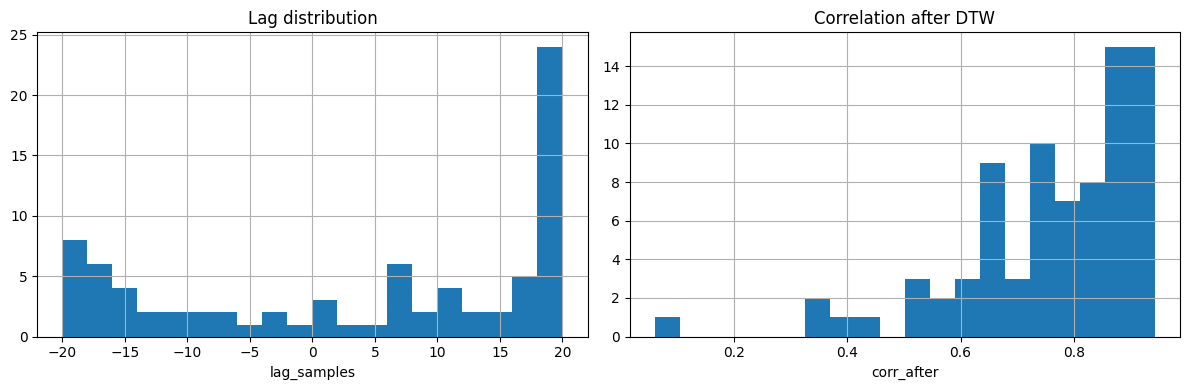

In [4]:
label_distribution = (
    DATASET_BUNDLE['metadata'][['emotion', 'modality', 'stimulus']]
    .value_counts()
    .rename('num_windows')
    .reset_index()
)
display(label_distribution.head(20))

alignment_summary = DATASET_BUNDLE['alignment_summary'][['lag_samples', 'correlation_after_dtw', 'dtw_normalized_distance']]
display(alignment_summary.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
DATASET_BUNDLE['alignment_summary']['lag_samples'].hist(ax=axes[0], bins=20)
axes[0].set_title('Lag distribution')
axes[0].set_xlabel('lag_samples')
DATASET_BUNDLE['alignment_summary']['correlation_after_dtw'].hist(ax=axes[1], bins=20)
axes[1].set_title('Correlation after DTW')
axes[1].set_xlabel('corr_after')
plt.tight_layout()


## Multitask experiment suite

The suite below runs the 7 experiment settings and reports the mean score across subject-group folds.


In [5]:
if not TORCH_READY:
    display(Markdown(f"**PyTorch is not available in the current `.venv`**: `{TORCH_IMPORT_ERROR}`"))
    SUITE_RESULT = None
else:
    SPLIT_CONFIG = SplitConfig(
        n_splits=5,
        random_state=42,
    )
    MODEL_CONFIG = ModelConfig(
        hidden_dim=128,
        dropout=0.1,
        trunk_blocks=2,
        modality_dropout_p=0.1,
    )
    TRAINING_CONFIG = TrainingConfig(
        batch_size=32,
        max_epochs=10,
        learning_rate=1e-3,
        weight_decay=1e-4,
        device='auto',
        domain_loss_weight=0.1,
        flat_tag_loss_weight=0.1,
        emotion_loss_weight=1.0,
        modality_loss_weight=1.0,
        stimulus_loss_weight=1.0,
        use_cb_focal=False,
    )
    SUITE_RESULT = run_experiment_suite(
        DATASET_BUNDLE,
        experiment_names=list(EXPERIMENT_SPECS.keys()),
        split_config=SPLIT_CONFIG,
        model_config=MODEL_CONFIG,
        training_config=TRAINING_CONFIG,
    )
    display(SUITE_RESULT['summary'])
    display(SUITE_RESULT['domain_gap_summary'])
    display(SUITE_RESULT['results_frame'])


/home/henriquesouza/IMUGPT/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1037: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/henriquesouza/IMUGPT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/henriquesouza/IMUGPT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/henriquesouza/IMUGPT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/henriquesouza/IMUGPT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1
0,vision_imu_mixed2r,0.481841,0.430202,0.275284,0.834600,0.335637
1,vision_imu_r2r,0.451124,0.384707,0.185454,0.833269,0.334649
2,vision_only,0.411155,0.349160,0.163175,0.837516,0.232775
3,imu_only_mixed2r,0.373785,0.334276,0.215751,0.597691,0.307912
4,imu_only_r2r,0.351068,0.304098,0.163188,0.604904,0.285113
5,vision_imu_s2r,0.338709,0.276550,0.090072,0.728906,0.197150
6,imu_only_s2r,0.225756,0.188407,0.076362,0.409183,0.191722


,metric,value
0,imu_only_gap_s2r,0.150145
1,imu_only_gap_mixed2r,-0.085167
2,imu_only_gain_mixed_over_r2r,0.085167
3,imu_only_gain_mixed_over_s2r,0.235312
4,vision_imu_gap_s2r,0.090207
5,vision_imu_gap_mixed2r,-0.075443
6,vision_imu_gain_mixed_over_r2r,0.075443
7,vision_imu_gain_mixed_over_s2r,0.165650


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1
0,vision_only,0.335905,0.294814,0.171541,0.670996,0.165179
1,vision_only,0.365018,0.293494,0.078921,0.768935,0.247198
2,vision_only,0.454284,0.398597,0.231537,0.930745,0.200569
3,vision_only,0.458414,0.381201,0.149561,0.970357,0.255324
4,vision_only,0.442155,0.377695,0.184314,0.846547,0.295605
5,imu_only_r2r,0.307657,0.256401,0.102632,0.602787,0.217551
6,imu_only_r2r,0.313795,0.262780,0.109732,0.509997,0.321657
7,imu_only_r2r,0.356429,0.312534,0.180847,0.581805,0.306636
8,imu_only_r2r,0.387956,0.345706,0.218954,0.582456,0.362458
9,imu_only_r2r,0.389504,0.343071,0.203775,0.747475,0.217262


## Optional confusion matrices

When the suite runs, this last block visualizes confusion matrices for the best experiment on its best fold.


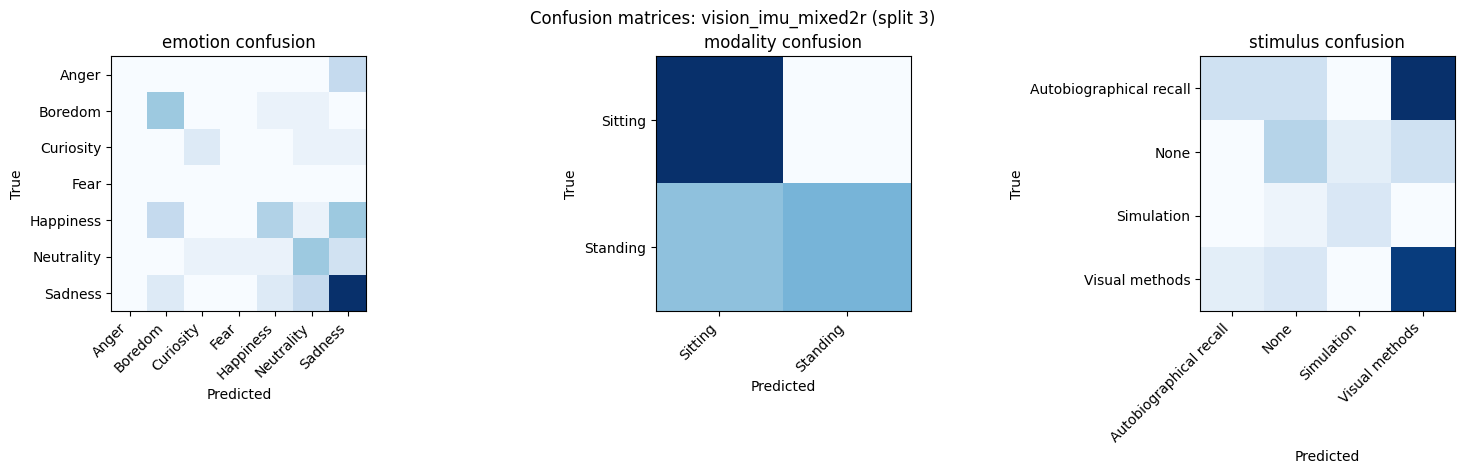

In [6]:
if SUITE_RESULT is not None:
    from evaluation.classifiers.metrics import plot_confusion_matrices

    best_experiment_name = SUITE_RESULT['summary'].iloc[0]['experiment_name']
    best_result = max(
        (
            result for result in SUITE_RESULT['results']
            if result['experiment_name'] == best_experiment_name
        ),
        key=lambda result: float(result['metrics'].get('global_score_macro_f1_mean') or float('-inf')),
    )
    best_split_id = best_result.get('split_id')
    fig, axes = plot_confusion_matrices(best_result['metrics'], DATASET_BUNDLE['label_encoders'])
    split_suffix = '' if best_split_id is None else f' (split {best_split_id})'
    fig.suptitle(f'Confusion matrices: {best_experiment_name}{split_suffix}', y=1.02)
    plt.show()
